# SAC Air Hockey Research Notebook

Deze notebook geeft een compacte maar diepgaande analyse-omgeving voor het evalueren van SAC-trainingruns, TensorBoard-logboeken, reward-profilevergelijkingen en modelprestaties.

Doel:
- training-logs visualiseren
- modelprestaties benchmarken op meerdere episodes
- verschillende reward-profielen vergelijken
- robotposities heatmaps genereren om edge-sticking en oppervlaktegebruik te controleren

Vanaf project-root kun je dit notebook direct uitvoeren.

In [1]:
from pathlib import Path
import sys


PROJECT_ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "ai" / "air_hockey_env.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root containing ai/air_hockey_env.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns

from stable_baselines3 import SAC



from ai.air_hockey_env import AirHockeyGymEnv

from research.analytics import (

    MODEL_ROOT,

    PROJECT_ROOT,

    TB_LOG_ROOT,

    collect_robot_positions,

    compare_reward_profiles,

    evaluate_model,

    find_tensorboard_runs,

    heatmap_robot_positions,

    load_tensorboard_metrics,

    plot_reward_profile_comparison,

    plot_tensorboard_metrics,

)



plt.style.use("seaborn-v0_8-whitegrid")

sns.set_context("notebook")

pd.set_option("display.max_columns", 30)



EVAL_EPISODES = 100

EVAL_SEED = 11

MAX_EPISODE_STEPS = 1000

DEFAULT_MODEL = MODEL_ROOT / "trained_sac_model.zip"



print(f"Project root: {PROJECT_ROOT}")

print(f"Reward profiles: {', '.join(AirHockeyGymEnv.REWARD_MODES)}")

print(f"TensorBoard run directories: {len(find_tensorboard_runs(TB_LOG_ROOT))}")

print(f"Default model exists: {DEFAULT_MODEL.is_file()} ({DEFAULT_MODEL})")

Project root: c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision
Reward profiles: aggressive, balanced, defensive
TensorBoard run directories: 0
Default model exists: True (c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\models\trained_sac_model.zip)


In [2]:
# 1. TensorBoard scalars: run-overlays and smoothed training reward



metrics = load_tensorboard_metrics(TB_LOG_ROOT)

available_tags = sorted(metrics)

print(f"Loaded {len(available_tags)} scalar tags from {TB_LOG_ROOT}")

print("Tags:", available_tags if available_tags else "No event files found")



# SB3 commonly prefixes the episode reward tag with rollout/.

reward_tag = next((tag for tag in ("rollout/ep_rew_mean", "ep_rew_mean") if tag in metrics), None)

key_tags = [reward_tag, "train/critic_loss", "train/actor_loss", "train/ent_coef"]

selected_tags = [tag for tag in key_tags if tag is not None and tag in metrics]



if selected_tags:

    figures = plot_tensorboard_metrics(metrics, selected_tags=selected_tags)

    plt.show()

else:

    print("No requested scalar tags were found; training-curve plots are skipped.")

Loaded 0 scalar tags from c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\sac_air_hockey_tensorboard
Tags: No event files found
No requested scalar tags were found; training-curve plots are skipped.


In [3]:
# 2. Reward trend and simple instability / overfitting signals



if reward_tag is not None:

    reward_frame = metrics[reward_tag].copy()

    reward_frame = reward_frame.sort_values(["run", "step"])

    reward_frame["rolling_reward"] = reward_frame.groupby("run")["value"].transform(

        lambda values: values.rolling(window=max(3, min(25, len(values) // 5 or 3)), min_periods=1).mean()

    )

    fig, ax = plt.subplots(figsize=(11, 5))

    sns.lineplot(data=reward_frame, x="step", y="value", hue="run", alpha=0.25, legend=False, ax=ax)

    sns.lineplot(data=reward_frame, x="step", y="rolling_reward", hue="run", ax=ax)

    ax.set(title="Episode reward: raw values and rolling mean", xlabel="Training steps", ylabel="Mean episode reward")

    ax.grid(True, alpha=0.25)

    fig.tight_layout()

    plt.show()

else:

    print("No episode-reward series available for trend analysis.")



for tag in ["train/critic_loss", "train/actor_loss", "train/ent_coef"]:

    if tag in metrics:

        frame = metrics[tag]

        print(f"{tag}: {len(frame):,} samples; {frame['run'].nunique()} run(s); "

              f"step range {frame['step'].min():,}-{frame['step'].max():,}")



print("Training curves can flag instability, but diagnosing overfitting requires held-out evaluation episodes.")

No episode-reward series available for trend analysis.
Training curves can flag instability, but diagnosing overfitting requires held-out evaluation episodes.


c:\Users\timoz\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute 'FloatSchedule' on <module 'stable_baselines3.common.utils' from 'c:\\Users\\timoz\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\stable_baselines3\\common\\utils.py'>
  warnings.warn(


,value
episodes,100.000000
goals_for,12.000000
goals_against,28.000000
wins,12.000000
draws,60.000000
win_rate,12.000000
goal_ratio,30.000000
goals_against_ratio,70.000000
avg_episode_length,808.110000
avg_episode_duration_s,6.734250


,episode,goals_for,goals_against,won,draw,episode_length,episode_duration_s,episode_return,shots,shots_per_minute,avg_mallet_speed,reaction_time_s
0,1,1,0,True,False,413,3.441667,15.640798,1,17.433414,1.332939,NaN
1,2,0,0,False,True,1000,8.333333,15.637528,1,7.200000,1.420397,0.558333
2,3,0,0,False,True,1000,8.333333,24.661812,2,14.400000,1.422563,0.033333
3,4,0,0,False,True,1000,8.333333,11.160323,0,0.000000,1.568062,1.025000
4,5,1,0,True,False,751,6.258333,16.168426,1,9.587217,1.353559,0.000000
5,6,0,0,False,True,1000,8.333333,15.358505,0,0.000000,1.222739,0.408333
6,7,0,1,False,False,949,7.908333,26.309483,3,22.760801,1.569619,0.000000
7,8,0,1,False,False,819,6.825000,20.695627,1,8.791209,1.407867,0.000000
8,9,0,0,False,True,1000,8.333333,18.648372,0,0.000000,1.445041,0.866667
9,10,0,0,False,True,1000,8.333333,45.677571,3,21.600000,1.226819,0.991667


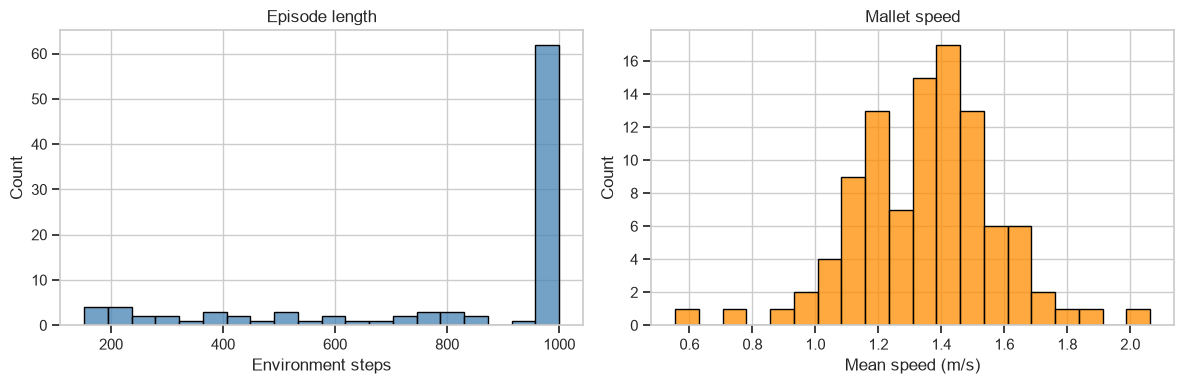

No TensorBoard episode-reward data for a train/evaluation gap comparison.


In [4]:
# 3. Deterministic model benchmark



if DEFAULT_MODEL.is_file():

    eval_df, summary = evaluate_model(

        model_path=DEFAULT_MODEL,

        episodes=EVAL_EPISODES,

        reward_mode="aggressive",

        max_steps=MAX_EPISODE_STEPS,

        seed=EVAL_SEED,

    )

    summary_df = pd.Series(summary, name="value").to_frame()

    display(summary_df)

    display(eval_df.head(10))



    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data=eval_df, x="episode_length", bins=20, ax=axes[0], color="steelblue")

    axes[0].set(title="Episode length", xlabel="Environment steps")

    sns.histplot(data=eval_df, x="avg_mallet_speed", bins=20, ax=axes[1], color="darkorange")

    axes[1].set(title="Mallet speed", xlabel="Mean speed (m/s)")

    fig.tight_layout()

    plt.show()



    if reward_tag is not None and reward_tag in metrics:

        training_tail = []

        for run_name, run_frame in metrics[reward_tag].groupby("run"):

            run_frame = run_frame.sort_values("step")

            tail_size = max(1, int(np.ceil(len(run_frame) * 0.1)))

            training_tail.append({"run": run_name, "training_reward": run_frame.tail(tail_size)["value"].mean()})

        train_eval_df = pd.DataFrame(training_tail).melt(

            id_vars="run", var_name="source", value_name="episode_reward"

        )

        train_eval_df = pd.concat([

            train_eval_df,

            pd.DataFrame({"run": ["held-out evaluation"], "source": ["evaluation_reward"],

                         "episode_reward": [summary["avg_episode_return"]]}),

        ], ignore_index=True)

        fig, ax = plt.subplots(figsize=(9, 4))

        sns.barplot(data=train_eval_df, x="run", y="episode_reward", hue="source", ax=ax)

        ax.set(title="Recent training reward vs held-out evaluation", xlabel="Training run", ylabel="Mean episode return")

        ax.tick_params(axis="x", rotation=20)

        fig.tight_layout()

        plt.show()

        print("Interpret the gap only when training and evaluation use the same reward profile and episode limits.")

    else:

        print("No TensorBoard episode-reward data for a train/evaluation gap comparison.")

else:

    eval_df = pd.DataFrame()

    summary = {}

    print(f"No trained model found at {DEFAULT_MODEL}; model benchmark is skipped.")

Models available: {'aggressive': 'c:\\Users\\timoz\\Documents\\00.school\\jaar 4\\New folder\\NHLstenden-Air-Hockey-Ai\\Orion Vision\\models\\trained_sac_model_aggressive.zip', 'balanced': 'c:\\Users\\timoz\\Documents\\00.school\\jaar 4\\New folder\\NHLstenden-Air-Hockey-Ai\\Orion Vision\\models\\trained_sac_model_bal.zip', 'defensive': 'c:\\Users\\timoz\\Documents\\00.school\\jaar 4\\New folder\\NHLstenden-Air-Hockey-Ai\\Orion Vision\\models\\trained_sac_modeldeftest1.zip'}


,win_rate,goal_ratio,goals_against_ratio,avg_episode_length,avg_shot_count,avg_shots_per_minute,avg_mallet_speed,avg_reaction_time_s
profile,,,,,,,,
aggressive,16.0,47.058824,52.941176,870.20,5.52,47.974596,1.289981,0.127717
balanced,20.0,47.619048,52.380952,830.52,51.38,374.890073,1.183049,0.312674
defensive,44.0,75.862069,24.137931,687.58,3.92,39.351978,1.174634,0.007246


c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\research\analytics.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profile_df, x="profile", y=metric, ax=axis, palette="magma")
c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\research\analytics.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profile_df, x="profile", y=metric, ax=axis, palette="magma")
c:\Users\timoz\Documents\00.school\jaar 4\New folder\NHLstenden-Air-Hockey-Ai\Orion Vision\research\analytics.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

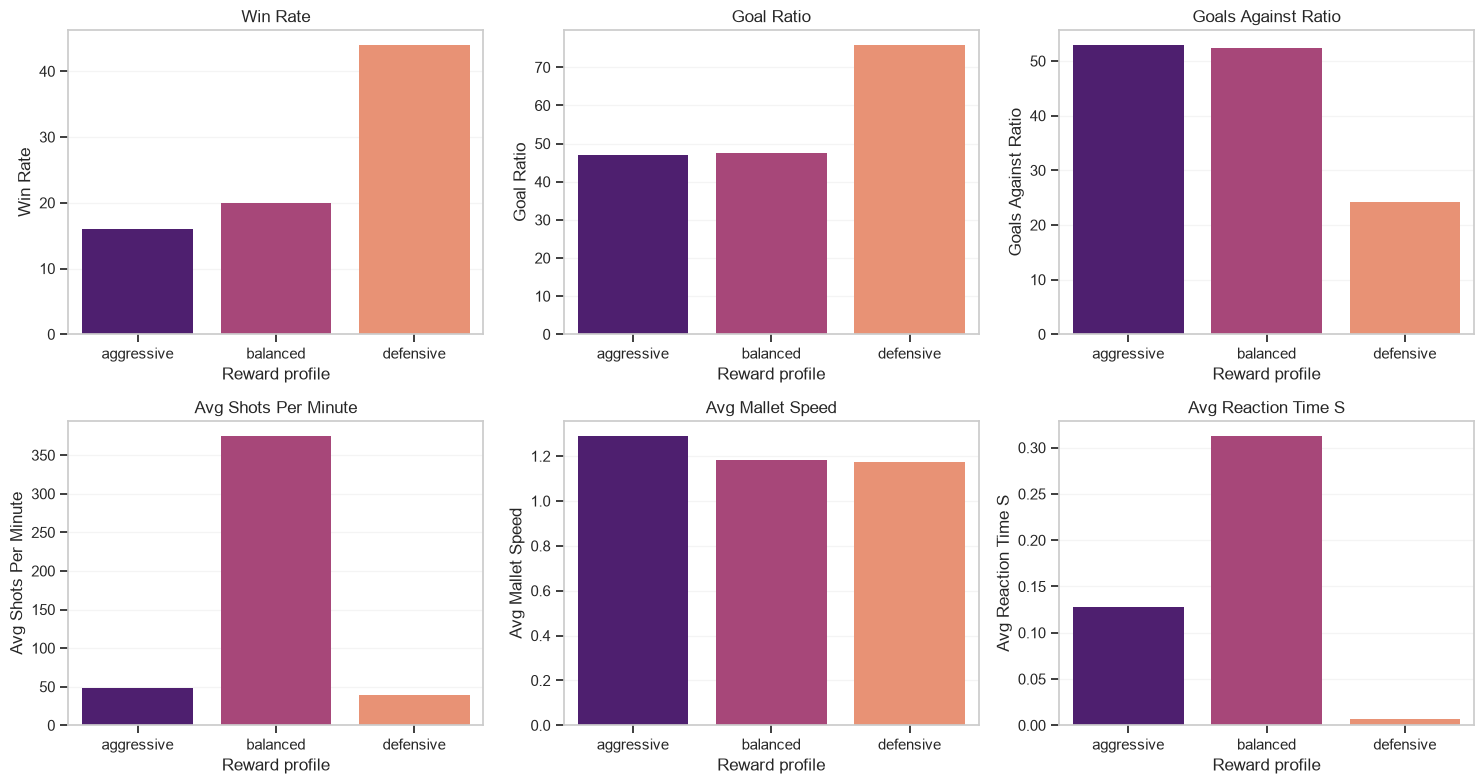

In [ ]:
# 4. A/B comparison: point each reward profile at its own trained model



PROFILE_MODELS = {

    "aggressive": MODEL_ROOT / "02trained_sac_model_aggressive.zip",

    "balanced": MODEL_ROOT / "02trained_sac_model_balanced.zip",

    "defensive": MODEL_ROOT / "02trained_sac_model_defensive.zip",

}

available_profiles = {

    profile: path for profile, path in PROFILE_MODELS.items()

    if path is not None and Path(path).expanduser().is_file()

}

missing_profiles = sorted(set(PROFILE_MODELS) - set(available_profiles))

print("Models available:", {name: str(path) for name, path in available_profiles.items()})

if missing_profiles:

    print("No model configured for:", ", ".join(missing_profiles),

          "(set PROFILE_MODELS to each profile's separately trained archive)")



if len(available_profiles) >= 2:

    profile_df = compare_reward_profiles(available_profiles, episodes=50)

    display(profile_df.set_index("profile"))

    plot_reward_profile_comparison(profile_df)

    plt.show()

else:

    profile_df = pd.DataFrame()

    print("A/B comparison needs at least two separately trained profile models; evaluation skipped.")

c:\Users\timoz\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: Can't get attribute 'FloatSchedule' on <module 'stable_baselines3.common.utils' from 'c:\\Users\\timoz\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\stable_baselines3\\common\\utils.py'>
  warnings.warn(


Collected 32,653 robot positions


,x_m,y_m
count,32653.000000,32653.000000
mean,-0.586824,0.109889
std,0.358644,0.304140
min,-0.927000,-0.442000
25%,-0.927000,-0.107589
50%,-0.741731,0.190697
75%,-0.170879,0.383235
max,-0.048000,0.442000


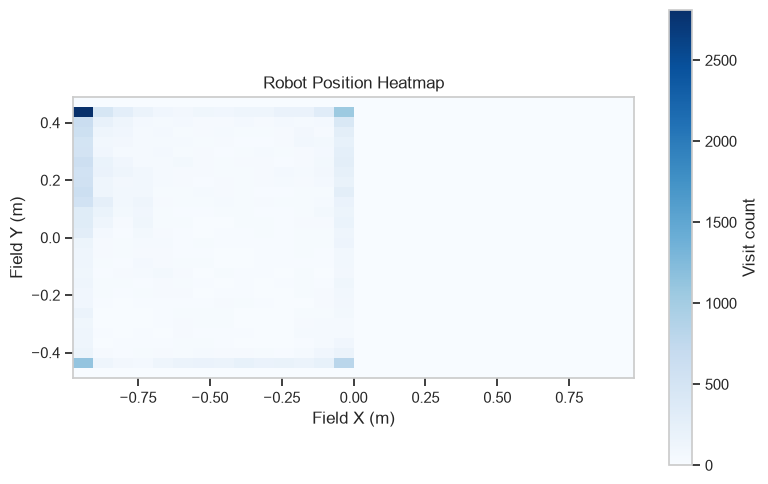

In [6]:
# 5. Position occupancy during deterministic test episodes



if DEFAULT_MODEL.is_file():

    robot_positions = collect_robot_positions(

        model_path=DEFAULT_MODEL,

        episodes=40,

        reward_mode="aggressive",

        max_steps=MAX_EPISODE_STEPS,

        seed=EVAL_SEED,

    )

    positions_array = np.asarray(robot_positions)

    print(f"Collected {len(positions_array):,} robot positions")

    display(pd.DataFrame(positions_array, columns=["x_m", "y_m"]).describe())

    heatmap_robot_positions([positions_array])

    plt.show()

else:

    print("Position heatmap skipped because the default model archive is unavailable.")

## Interpretatie en methodologie



- `rollout/ep_rew_mean` (of `ep_rew_mean`) toont de trainingsreward; critic loss, actor loss en entropie helpen instabiliteit en voortijdige convergentie te signaleren.

- Alleen trainingscurves bewijzen geen overfitting. Vergelijk ze met deterministische evaluatieruns die niet voor training zijn gebruikt.

- `win_rate` is het aandeel episodes waarin de robot meer goals scoort dan de tegenstander. `goal_ratio` en `goals_against_ratio` verdelen alle goals voor/tegen.

- Een schot is hier een robot-malletcontact waarna de puck richting het doel van de tegenstander beweegt. Schotfrequentie wordt genormaliseerd per speelminuut.

- Reactietijd is de tijd vanaf het moment dat de puck de robothelft in beweegt tot de mallet aantoonbaar richting puck beweegt. Episodes zonder zo'n reactie tellen niet mee in het gemiddelde (`NaN`).

- Voor een eerlijke A/B-test moeten `PROFILE_MODELS` naar aparte modellen wijzen die elk met het genoemde reward-profiel zijn getraind. Alle profielen worden op dezelfde seed-reeks geëvalueerd.

- De heatmap toont bezochte robotposities in meters; langdurige concentratie langs een rand kan duiden op beperkt veldgebruik.



De helpers in `research/analytics.py` zijn ook los van deze notebook vanuit Python aan te roepen.